# Data Analysis Graph

This notebook implements a LangGraph workflow for data analysis using AI agents.

## Setup and Configuration

In [134]:
# Import required libraries
import sys
from pathlib import Path

# Add project root to path
project_root = Path().absolute().parent.parent.parent
sys.path.insert(0, str(project_root))

# Import settings
from src.config import settings

print(f"Application: {settings.app_name}")
print(f"Version: {settings.app_version}")
print(f"Default LLM Model: {settings.default_llm_model}")
print(f"Temperature: {settings.default_llm_temperature}")


Application: Data Agent LangGraph
Version: 0.1.0
Default LLM Model: gpt-4o
Temperature: 0.7


## Import Dependencies

In [135]:
from typing import TypedDict, Annotated
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain_anthropic import ChatAnthropic
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage
import pandas as pd
import numpy as np
from typing import Any, Optional, List

## State definition

In [136]:
# create custom reducers

from typing import Dict


def reduce_search_payload(left: Dict[str,str] | None, right: Dict[str,str] | None) -> list:
    """Safely combine two lists, handling cases where either or both inputs might be None.

    Args:
        left (list | None): The first list to combine, or None.
        right (list | None): The second list to combine, or None.

    Returns:
        list: A new list containing all elements from both input lists.
               If an input is None, it's treated as an empty list.
    """
    if not left:
        left = {}
    if not right:
        right={}
        
    left_copy=left.copy()
    
    left_copy.update(right)
        
    return left_copy


In [137]:
from typing import Dict
from src.graphs.custom_reducers.reduce_search_payload import reduce_search_payload
from src.graphs.state_definitions.overall_state import SearchPayload

class OverallState(TypedDict):
    messages: Annotated[list, add_messages]
    intent: Optional[str]
    search_attributes: Optional[list[str]]
    search_payload: Annotated[SearchPayload,reduce_search_payload]

## Init LLM

In [138]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model=settings.default_llm_model, 
    temperature=settings.default_llm_temperature,
    api_key=settings.openai_api_key
)

## Intent classification node

In [139]:

from typing import Literal
from pydantic import BaseModel, Field
from src.graphs.prompts.intent_classification import INTENT_CLASSIFICATION_PROMPT

class IntentClassificationOutput(BaseModel):
    intent: Literal["search", "document_accuracy", "document_counter", "document_processing_time", "others"] = Field(
        ..., 
        description="The user's intent based on the conversation."
    )    
    reasoning: str = Field(..., description="The reasoning behind the intent classification.")


def intent_classifier(state: OverallState):
    print("\n 🟢 I am in intent classifier node")
    
    structured_llm = llm.with_structured_output(IntentClassificationOutput)
    
    output = structured_llm.invoke([SystemMessage(content=INTENT_CLASSIFICATION_PROMPT)] + state["messages"])
    
    print("llm_output: ", output)
    
    return {"intent": output.intent,"messages":[AIMessage(content=output.reasoning)]}

## Request user input for edge cases:

In [140]:
def user_input_clarity(state:OverallState):
    pass

## Conditional routing for intent

In [141]:

def routing_intent(state: OverallState):
    print("\n ⭐ I am in routing intent")
    
    if state['intent'] in ["document_accuracy", "document_counter", "document_processing_time"]:
        print("routing business parameters intent")
        return "document parameters intent"
    
    if state['intent'] == 'others':
        # human in the loop ask user to input again
        print("intent is unclear, request user query refinement")
        return "unclear intent"
    
    print("routing to search intent")
    return "search intent"

## Extract search attrbutes node for search query

In [142]:
from src.graphs.prompts.search_attributes_extraction import SEARCH_ATTRIBUTES_EXTRACTION_PROMPT

# Pydantic model for LLM response
class AttributesExtraction(BaseModel):
    """Classification of user intent"""
    attributes: List[Literal["document_model", "queue", "date"]] = Field(
        description="The attributes that need to be extracted. Must only contain: document model, queue, or date"
    )
    reasoning: str


# Node 2: Search Node (placeholder)
def extract_search_attributes_from_query(state: OverallState) -> dict:
    """Placeholder search node - empty for now"""
    
    print("\n 🍿 I am in extracing search attributes from query node")
    
    # Use structured output with Pydantic
    structured_llm = llm.with_structured_output(AttributesExtraction)
    
    messages = [SystemMessage(content=SEARCH_ATTRIBUTES_EXTRACTION_PROMPT)] + state['messages']
    
    result: AttributesExtraction = structured_llm.invoke(messages)
    
    print("extracted attributed result: ",result)
    
    if not result.attributes:
        print("There are no valid attributes can be extracted from your query")
    else:
        print(f"Valid extracted attributes: {', '.join(result.attributes)}")
    
    
    return {
        "search_attributes": result.attributes,
        "messages":[AIMessage(content=result.reasoning)]
    }

## Conditional routing for extracted search query 

In [143]:
def routing_extracted_search_attributes(state: OverallState):
    print("\n 🍺 I am in routing extracted search attributes")
    
    search_attributes=state['search_attributes']
    
    if not search_attributes:
        print("There are no valid search attributes")
        print("request user query refinement")
        return "vague search query"
    
    print("valid search query => routing to processing search attributes")
    return "valid search query"

## Routing processing search attributes

In [144]:

def router_processing_search_attributes(state: OverallState):
    return {}

def routing_processing_search_attributes(state: OverallState):
    print("\n 🔥 I am in routing processing search attributes")
    
    search_attributes=state['search_attributes']
    
    if not search_attributes:
        print("complete all processing")
        return "complete processing"
    
    if "queue" in search_attributes:
        print("routing to queue processing sub graph")
        return "processing queue attribute"
    
    if "document_model" in search_attributes:
        print("routing to document model processing sub graph")
        return "processing document model attribute"
    

## Processing Search Attribute Node

In [145]:
def processing_queue_search_attribute_node(state: OverallState):
    return {}

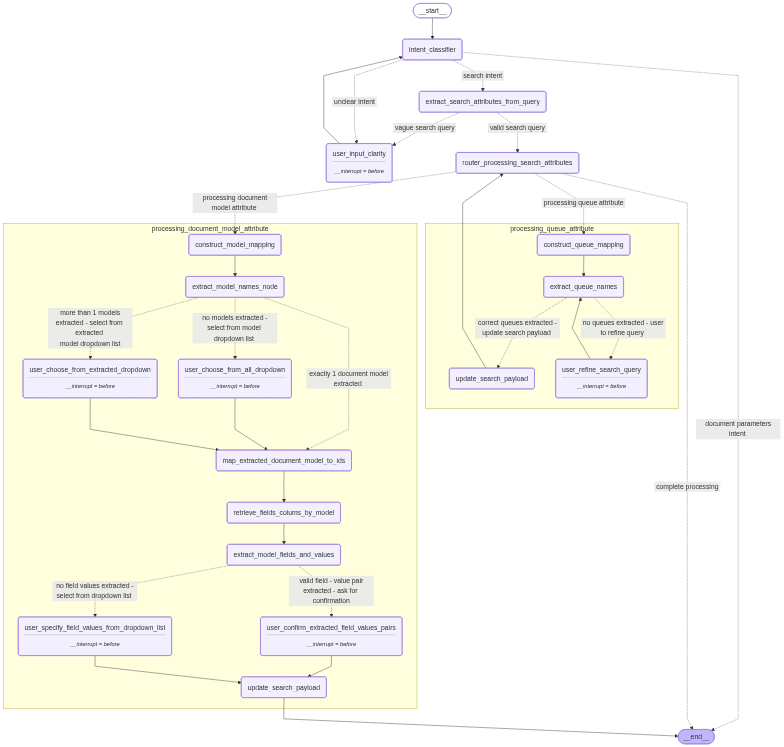

In [146]:
from IPython.display import Image, display
from langgraph.checkpoint.memory import MemorySaver
from src.graphs.sub_graphs.queue_processing_graph import create_queue_processing_graph
from src.graphs.sub_graphs.document_model_processing_graph import create_document_model_processing_graph
  
memory = MemorySaver()

test_builder=StateGraph(OverallState)

test_builder.add_node("intent_classifier",intent_classifier)
test_builder.add_node("user_input_clarity",user_input_clarity)
test_builder.add_node("extract_search_attributes_from_query",extract_search_attributes_from_query)
test_builder.add_node("router_processing_search_attributes",router_processing_search_attributes)
test_builder.add_node("processing_queue_attribute",create_queue_processing_graph(llm=llm,checkpointer=memory))
test_builder.add_node("processing_document_model_attribute",create_document_model_processing_graph(llm=llm,checkpointer=memory))


test_builder.add_edge(START,"intent_classifier")
test_builder.add_conditional_edges("intent_classifier", 
                                   routing_intent, 
                                   {"unclear intent":"user_input_clarity", 
                                    "search intent":"extract_search_attributes_from_query",
                                    "document parameters intent":END}
                                   )
test_builder.add_edge("user_input_clarity","intent_classifier")
test_builder.add_conditional_edges("extract_search_attributes_from_query", 
                                   routing_extracted_search_attributes, 
                                   {"vague search query":"user_input_clarity",
                                    "valid search query":"router_processing_search_attributes"})
test_builder.add_conditional_edges("router_processing_search_attributes", 
                                   routing_processing_search_attributes, 
                                   {"processing queue attribute":"processing_queue_attribute",
                                    "processing document model attribute":"processing_document_model_attribute",
                                    "complete processing":END})
test_builder.add_edge("processing_queue_attribute","router_processing_search_attributes")


# Compile
graph = test_builder.compile(interrupt_before=["user_input_clarity"],checkpointer=memory)

# View
display(Image(graph.get_graph(xray=1).draw_mermaid_png()))

In [147]:
# graph.invoke({"messages": [HumanMessage(content="I want to search all documents from queue xyz from 1/11/2025 to now and from invoice model")]})

# graph.invoke({"messages": [HumanMessage(content="I want to know the document processing time")]})
thread = {"configurable": {"thread_id": "3"}}

# graph.invoke({"messages": [HumanMessage(content="I wanna search documents belong to queues containing Louis")]},thread)
graph.invoke({"messages": [HumanMessage(content="I wanna search documents with queue containing Josh from invoice model with Invoice number is 34ictgh789 and Invoice date is 25th November 2025 and Customer Name is DBS Bank ")]},thread)


 🟢 I am in intent classifier node
llm_output:  intent='search' reasoning="The user is requesting to search for documents with specific criteria including queue name, invoice model, invoice number, invoice date, and customer name, which fits the 'search' intent."

 ⭐ I am in routing intent
routing to search intent

 🍿 I am in extracing search attributes from query node
extracted attributed result:  attributes=['document_model', 'queue', 'date'] reasoning="The user wants to filter documents by queue containing 'Josh', document type 'invoice', and the date '25th November 2025'. Other details like Invoice number and Customer Name are not part of the allowed attributes."
Valid extracted attributes: document_model, queue, date

 🍺 I am in routing extracted search attributes
valid search query => routing to processing search attributes

 🔥 I am in routing processing search attributes
routing to queue processing sub graph

 💡 I am in construct_queue_mapping node
 I am making graph QL call to 

{'messages': [HumanMessage(content='I wanna search documents with queue containing Josh from invoice model with Invoice number is 34ictgh789 and Invoice date is 25th November 2025 and Customer Name is DBS Bank ', additional_kwargs={}, response_metadata={}, id='533384ca-b2e6-4202-bf0a-a3c182f58348'),
  AIMessage(content="The user is requesting to search for documents with specific criteria including queue name, invoice model, invoice number, invoice date, and customer name, which fits the 'search' intent.", additional_kwargs={}, response_metadata={}, id='d06bfd57-da10-4714-bf9a-8c39620e7128'),
  AIMessage(content="The user wants to filter documents by queue containing 'Josh', document type 'invoice', and the date '25th November 2025'. Other details like Invoice number and Customer Name are not part of the allowed attributes.", additional_kwargs={}, response_metadata={}, id='5b8a3b68-1491-406b-8d44-b2f188e02cb1'),
  AIMessage(content="The user mentioned searching for documents in a queue

In [148]:
state = graph.get_state(thread)
state

StateSnapshot(values={'messages': [HumanMessage(content='I wanna search documents with queue containing Josh from invoice model with Invoice number is 34ictgh789 and Invoice date is 25th November 2025 and Customer Name is DBS Bank ', additional_kwargs={}, response_metadata={}, id='533384ca-b2e6-4202-bf0a-a3c182f58348'), AIMessage(content="The user is requesting to search for documents with specific criteria including queue name, invoice model, invoice number, invoice date, and customer name, which fits the 'search' intent.", additional_kwargs={}, response_metadata={}, id='d06bfd57-da10-4714-bf9a-8c39620e7128'), AIMessage(content="The user wants to filter documents by queue containing 'Josh', document type 'invoice', and the date '25th November 2025'. Other details like Invoice number and Customer Name are not part of the allowed attributes.", additional_kwargs={}, response_metadata={}, id='5b8a3b68-1491-406b-8d44-b2f188e02cb1'), AIMessage(content="The user mentioned searching for docum

In [149]:
state.next

('processing_document_model_attribute',)

In [150]:
# graph.invoke(None,thread)

In [151]:
main_state = graph.get_state(thread)
main_state.tasks

(PregelTask(id='0ffb33a4-27cb-de9e-a2b7-af70c65c9223', name='processing_document_model_attribute', path=('__pregel_pull', 'processing_document_model_attribute'), error=None, interrupts=(), state={'configurable': {'thread_id': '3', 'checkpoint_ns': 'processing_document_model_attribute:0ffb33a4-27cb-de9e-a2b7-af70c65c9223'}}, result=None),)

In [152]:
main_state = graph.get_state(thread)
subgraph_task = main_state.tasks[0]  # Get the first task
subgraph_checkpoint_config = subgraph_task.state  # This has the subgraph's checkpoint info

In [153]:
subgraph_checkpoint_config

{'configurable': {'thread_id': '3',
  'checkpoint_ns': 'processing_document_model_attribute:0ffb33a4-27cb-de9e-a2b7-af70c65c9223'}}

In [154]:
subgraph_state = graph.get_state(subgraph_checkpoint_config)
subgraph_state.next

('user_confirm_extracted_field_values_pairs',)

In [155]:
# Update the SUBGRAPH's state
graph.update_state(
      subgraph_checkpoint_config,  # Use subgraph's config, not main thread
      {
        "messages": [HumanMessage(content="Additional message")],
      }
)


 🚀 I am in routing_based_on_extracted_field_value_pairs
map_fields_to_values:  [{'name': 'InvoiceNumber', 'value': '34ictgh789'}, {'name': 'InvoiceDate', 'value': '25th November 2025'}, {'name': 'CustomerName', 'value': 'DBS Bank'}]
There are valid field values extracted from user query - ask user for confirmation


{'configurable': {'thread_id': '3',
  'checkpoint_ns': 'processing_document_model_attribute:0ffb33a4-27cb-de9e-a2b7-af70c65c9223',
  'checkpoint_id': '1f0d5a9b-c340-620a-8006-a1f30f73c259',
  'checkpoint_map': {'': '1f0d5a9b-989b-664e-8005-5d94261ad1c2',
   'processing_document_model_attribute:0ffb33a4-27cb-de9e-a2b7-af70c65c9223': '1f0d5a9b-c340-620a-8006-a1f30f73c259'}}}

In [156]:
graph.invoke(None,thread)


 🚀 I am in update_search_payload node


{'messages': [HumanMessage(content='I wanna search documents with queue containing Josh from invoice model with Invoice number is 34ictgh789 and Invoice date is 25th November 2025 and Customer Name is DBS Bank ', additional_kwargs={}, response_metadata={}, id='533384ca-b2e6-4202-bf0a-a3c182f58348'),
  AIMessage(content="The user is requesting to search for documents with specific criteria including queue name, invoice model, invoice number, invoice date, and customer name, which fits the 'search' intent.", additional_kwargs={}, response_metadata={}, id='d06bfd57-da10-4714-bf9a-8c39620e7128'),
  AIMessage(content="The user wants to filter documents by queue containing 'Josh', document type 'invoice', and the date '25th November 2025'. Other details like Invoice number and Customer Name are not part of the allowed attributes.", additional_kwargs={}, response_metadata={}, id='5b8a3b68-1491-406b-8d44-b2f188e02cb1'),
  AIMessage(content="The user mentioned searching for documents in a queue

In [157]:
state = graph.get_state(thread)
state.next

()

In [158]:
main_state = graph.get_state(thread)
main_state.tasks

()

In [159]:
main_state = graph.get_state(thread)
subgraph_task = main_state.tasks[0]  # Get the first task
subgraph_checkpoint_config = subgraph_task.state  # This has the subgraph's checkpoint info

IndexError: tuple index out of range

In [ ]:
subgraph_checkpoint_config

{'configurable': {'thread_id': '3',
  'checkpoint_ns': 'processing_document_model_attribute:540ce93b-c542-ecb7-43ad-35b5acb22565'}}

In [ ]:
subgraph_state = graph.get_state(subgraph_checkpoint_config)
subgraph_state.next

('user_choose_from_all_dropdown',)

In [ ]:
# Update the SUBGRAPH's state
graph.update_state(
      subgraph_checkpoint_config,  # Use subgraph's config, not main thread
)


 🚀 I am in routing_based_on_extracted_documents_models
extracted_documents_models:  []
there are no valid document models in user query


{'configurable': {'thread_id': '3',
  'checkpoint_ns': 'processing_document_model_attribute:540ce93b-c542-ecb7-43ad-35b5acb22565',
  'checkpoint_id': '1f0d43a8-492b-6c44-8003-beec1d0d0a6b',
  'checkpoint_map': {'': '1f0d43a8-33a8-6db8-8006-7b6edeb899e0',
   'processing_document_model_attribute:540ce93b-c542-ecb7-43ad-35b5acb22565': '1f0d43a8-492b-6c44-8003-beec1d0d0a6b'}}}

In [ ]:
graph.invoke(None,thread)


 🚀 I am in map_extracted_document_model_to_ids


KeyError: 'model'

In [ ]:
# graph.invoke({"messages": [HumanMessage(content="I want to search all documents from queue xyz from 1/11/2025 to now and from invoice model")]})

# graph.invoke({"messages": [HumanMessage(content="I want to know the document processing time")]})
thread = {"configurable": {"thread_id": "4"}}

# graph.invoke({"messages": [HumanMessage(content="I wanna search documents belong to queues containing Louis")]},thread)
graph.invoke({"messages": [HumanMessage(content="I wanna search documents")]},thread)


 🟢 I am in intent classifier node
llm_output:  intent='search' reasoning="The user is expressing a desire to search for documents, which aligns with the 'search' intent where users are looking to find documents based on specific criteria."

 ⭐ I am in routing intent
routing to search intent

 🍿 I am in extracing search attributes from query node
extracted attributed result:  attributes=[] reasoning="The query is too vague and doesn't specify any of the allowed search attributes such as document type, queue, or date."
There are no valid attributes can be extracted from your query

 🍺 I am in routing extracted search attributes
There are no valid search attributes
request user query refinement


{'messages': [HumanMessage(content='I wanna search documents', additional_kwargs={}, response_metadata={}, id='a23678d2-844d-4990-b644-16ab3d7e640b'),
  AIMessage(content="The user is expressing a desire to search for documents, which aligns with the 'search' intent where users are looking to find documents based on specific criteria.", additional_kwargs={}, response_metadata={}, id='35f8e4a4-ac84-4240-8ae3-9c3115912562'),
  AIMessage(content="The query is too vague and doesn't specify any of the allowed search attributes such as document type, queue, or date.", additional_kwargs={}, response_metadata={}, id='4bad819c-1452-43ce-91a0-f2605a54fc7f')],
 'intent': 'search',
 'search_attributes': [],
 'search_payload': {}}

In [ ]:
state = graph.get_state(thread)
state

StateSnapshot(values={'messages': [HumanMessage(content='I wanna search documents', additional_kwargs={}, response_metadata={}, id='a23678d2-844d-4990-b644-16ab3d7e640b'), AIMessage(content="The user is expressing a desire to search for documents, which aligns with the 'search' intent where users are looking to find documents based on specific criteria.", additional_kwargs={}, response_metadata={}, id='35f8e4a4-ac84-4240-8ae3-9c3115912562'), AIMessage(content="The query is too vague and doesn't specify any of the allowed search attributes such as document type, queue, or date.", additional_kwargs={}, response_metadata={}, id='4bad819c-1452-43ce-91a0-f2605a54fc7f')], 'intent': 'search', 'search_attributes': [], 'search_payload': {}}, next=('user_input_clarity',), config={'configurable': {'thread_id': '4', 'checkpoint_ns': '', 'checkpoint_id': '1f0d595f-9172-6a80-8002-8d4082397b51'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2025-12-10T07:00:55.437360+00:00', pa

In [ ]:
state.next

('user_input_clarity',)